# Economic Surprise Index — a quantitative teardown 🔬
### A transparent CESI proxy from 6 FRED series · conditional vs unconditional forward returns · a Welch *t* + placebo null · an ESI-timing-vs-buy-and-hold Sharpe race · a synthetic faithful-engine / power control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Free_nowcast%3F: Busted](https://img.shields.io/badge/Free_nowcast%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We separate the two things "buy the beat" fuses: a **real but small** post-beat drift from the **unconditional up-drift** of US equities, and we confront both with the sample's **standard error**. The decisive object is not the point estimate (it's positive, as the lore says) but its **power** — and whether a timing rule built on it can clear buy-and-hold.

> ⚠️ **Data + proxy note.** Citi's CESI is proprietary and there's no free history of analyst forecasts; we build a transparent **proxy** — six monthly FRED real-activity series (payrolls, IP, retail sales, sentiment, housing, durable orders), each differenced against its **trailing-12-month average** (a labelled consensus stand-in), z-scored and averaged. That construction is the methodological knife: a surprise measured against a trailing mean is mechanically an **autocorrelation** signal aligned with post-recession recovery. Real data: FRED + yfinance SPY, 1993→2026, month-end. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from economic_surprise_index import data, strategy as st

HAVE_REAL = data.have_real()
F = data.build_real() if HAVE_REAL else None
print("real FRED+SPY cache present:", HAVE_REAL,
      "| monthly observations:", (0 if F is None else len(F)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '1993-01-31', 'end': '2026-05-31', 'months': 401, 'years': 33.3, 'esi_mean': -0.08, 'esi_std': 1.19, 'esi_frac_pos': 48, 'h1': (1, 191, 0.92, 64, 0.96, 65, -0.1, 0.549), 'h3': (3, 190, 2.87, 72, 2.83, 72, 0.06, 0.473), 'h6': (6, 187, 6.6, 80, 5.79, 76, 0.89, 0.148), 'h12': (12, 184, 13.38, 88, 12.01, 82, 1.0, 0.134), 'timing': [('long / flat', 48, 215, 6.3, 9.5, 0.66, 0.78), ('long / short', 100, 429, 1.0, 15.1, 0.07, 0.78)], 'robust': [(-0.5, 337, 11.7, -0.23, 0.62), (0.0, 184, 13.4, 1.0, 0.134), (0.5, 54, 13.7, 0.78, 0.234)], 'syn': [(0.0, 208, 4.77, 4.38, 0.47, 0.267), (0.04, 208, 12.4, 8.48, 2.22, 0.003)]}


real FRED+SPY cache present: True | monthly observations: 401


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | 12-month conditional mean **+13.4%** vs base **+12.0%**; Welch **t = 1.00**, placebo **p = 0.13** — positive but **fails t ≥ 2**, and the 1-month *t* is **-0.10** (the horizon news actually moves). |
| **Tradability** | `MIRAGE` | ESI>0 timing rule net Sharpe **0.66** (long/flat) / **0.07** (long/short) vs buy-and-hold **0.78** — it **loses to holding**, before even crediting the cash yield it ignores while flat. |
| **Free nowcast?** | `BUSTED` | The 12m win-rate **88%** vs an unconditional **82%** — the 'edge' is base rate × recovery drift. |

> 💡 In plain words: the beat really does precede gains — because *almost everything* precedes gains in an up-drifting market, and a trailing-average surprise runs hot right during recoveries. Strip the base rate and the excess is a whisper the null explains.

## 1 · The claim, steelmanned

Let $x_{i,t}$ be series $i$'s month-$t$ change (log-growth or level-diff). The **surprise** differences it against a trailing-12m consensus proxy and standardizes by a trailing-36m std: $z_{i,t} = (x_{i,t} - \overline{x}_{i,t-1:t-12}) / \hat\sigma_{i,t}$, and $\mathrm{ESI}_t = \frac1n\sum_i z_{i,t}$. A **beat** month is $\mathrm{ESI}_{t} > 0$, acted on at $t+1$ (one-month lag).

- **H₁ (the signal predicts).** $\mathbb{E}[r_{t\to t+H}\mid \text{beat}] > \mathbb{E}[r_{t\to t+H}]$ for forward horizon $H$ — a *positive excess* over the base rate.
- **H₂ (it's deployable).** A timing rule that holds SPY on beats clears buy-and-hold net of costs.
- **H₃ ("free nowcast").** The high post-beat win-rate reflects the signal, not the market's unconditional up-drift × the recovery-aligned construction.

We find **H₁ not rejected but not supported** (positive, $t < 2$, ~zero at 1–3m), **H₂ rejected** (the rule loses to holding), **H₃ rejected** (the win-rate ≈ the base rate). The legend is true exactly where it's uninformative (the market goes up) and unproven exactly where it would pay (a *distinct* nowcast).

## 2 · So what? — what rides on each answer

The whole teardown is one decomposition: a conditional mean against an unconditional baseline, judged by its **standard error**.

$$\widehat{\Delta}_H = \bar r^{\text{beat}}_H - \bar r^{\text{all}}_H,\qquad t = \frac{\widehat{\Delta}_H}{\sqrt{\,s^2_{\text{beat}}/k + s^2_{\text{all}}/N\,}}.$$

A raw **win-rate** is the wrong lens: US 12-month returns are positive ~80% of the time *unconditionally*, so an 88% conditional rate is barely a standard error of a proportion away from the null. The honest instruments are a **Welch two-sample t** on the conditional vs unconditional means and a **randomization (placebo) null** — resample $k$ random entry dates and ask how often chance matches the beats. And because a real point estimate is worthless if it can't be deployed, the **Tradability** axis is settled by a separate object entirely: a net-of-cost **Sharpe race** against buy-and-hold.

## 3 · How we'd know — the protocol

- **Surprise index.** Six FRED monthly series (yfinance SPY), 1993-01-31→2026-05-31, **401 months**. Each surprise = change − trailing-12m mean, z-scored on a trailing-36m std, averaged. Explicit **proxy** for CESI; the trailing-average consensus is named on the Signal axis as an autocorrelation confound.
- **Beat months.** $\mathrm{ESI}_t > 0$, entered the close **1 month after** the signal (no look-ahead); hold $H\in\{1,3,6,12\}$ months.
- **Null #1 (Welch t).** Conditional mean vs the unconditional overlapping-window mean.
- **Null #2 (placebo).** 20,000 draws of $k$ random valid entry dates; $p = \Pr[\text{random-draw mean} \ge \text{beat mean}]$ — the small-sample workhorse.
- **Timing backtest.** Long/flat (or long/short) SPY held when ESI>0, 1-month lag, 10-bps one-way per turn, raced against buy-and-hold on a Sharpe basis (price-only, labelled).
- **Positive control.** A deterministic monthly series (AR(1) surprise + SPY-like price) with a **known** planted forward edge: the inference must recover a planted edge **and** must NOT manufacture significance when the true edge is zero.

## 4 · The teardown

### 4a · The point estimates — positive, small, front-loaded with nothing

Conditional mean forward return with its $\pm$ standard error, against the unconditional base rate (diamonds). Positive and growing with horizon — but the excess is tiny and the 1–3-month bars (where a release moves price) sit *on* the base rate.

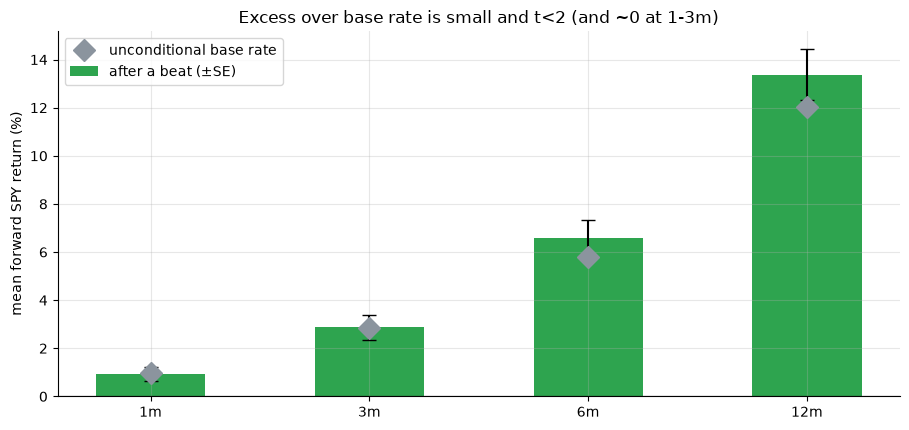

Welch t by horizon: {'1m': -0.1, '3m': 0.06, '6m': 0.89, '12m': 1.0}


In [2]:
hs = [1, 3, 6, 12]
if HAVE_REAL:
    cm, bm, ts, ses = [], [], [], []
    for m in hs:
        s = st.summarize(F, m); cm.append(s['cond_mean']); bm.append(s['base_mean']); ts.append(s['t'])
        cr = st.conditional_returns(F, m); ses.append(cr.std(ddof=1)/np.sqrt(len(cr)))
else:
    cm = [R['h1'][2]/100, R['h3'][2]/100, R['h6'][2]/100, R['h12'][2]/100]
    bm = [R['h1'][4]/100, R['h3'][4]/100, R['h6'][4]/100, R['h12'][4]/100]
    ts = [R['h1'][6], R['h3'][6], R['h6'][6], R['h12'][6]]; ses = [0.01, 0.018, 0.028, 0.045]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x, [c*100 for c in cm], yerr=[s*100 for s in ses], capsize=5, color=GREEN, width=.5, label='after a beat (±SE)')
ax.plot(x, [b*100 for b in bm], 'D', ms=11, c=GREY, label='unconditional base rate')
ax.set_xticks(x); ax.set_xticklabels([f'{m}m' for m in hs]); ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('mean forward SPY return (%)')
ax.set_title('Excess over base rate is small and t<2 (and ~0 at 1-3m)'); ax.legend()
plt.tight_layout(); plt.show()
print('Welch t by horizon:', {f'{m}m': round(t,2) for m,t in zip(hs,ts)})

> 💡 In plain words: at 12 months the beat mean is **+13.4%** vs a base **+12.0%** — a ~1.4-point bump at **t = 1.00** (not significant). At 1 month — where a release moves the tape — it's **t = -0.10** (*below* base). H₁ is **not rejected, not supported**: a positive whisper inside its own error bar, absent exactly where the information is supposed to live.

### 4b · The decisive test — a placebo null sized to the event count

Draw 184 *random* entry dates 20,000 times; the histogram is the null distribution of the 12-month mean. The beat months are the green line; the *p*-value is the right-tail mass.

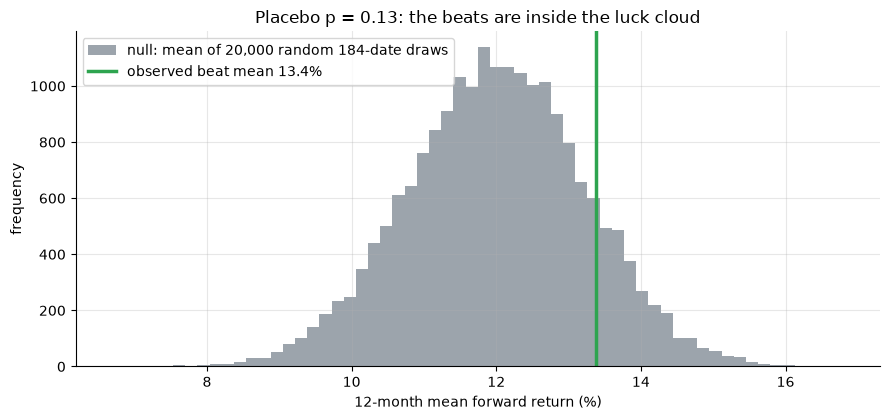

P[random 184-date draw >= beat] = 0.134  (need <0.05 to call it real; here ~1 in 7)


In [3]:
if HAVE_REAL:
    pl = st.placebo_pvalue(F, 12); obs = pl['cond_mean']; pval = pl['p_value']
    fwd = st.forward_returns(F['spy'], 12).dropna().values; n=len(fwd); k=pl['k']
    rng = np.random.default_rng(387)
    draws = np.array([fwd[rng.integers(0,n,size=k)].mean() for _ in range(20000)])
else:
    obs = R['h12'][2]/100; pval = R['h12'][7]; k = R['h12'][1]
    rng = np.random.default_rng(387); draws = rng.normal(R['h12'][4]/100, 0.012, 20000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws*100, bins=60, color=GREY, alpha=.85, label=f'null: mean of {len(draws):,} random {k}-date draws')
ax.axvline(obs*100, c=GREEN, lw=2.5, label=f'observed beat mean {obs*100:.1f}%')
ax.set_xlabel('12-month mean forward return (%)'); ax.set_ylabel('frequency')
ax.set_title(f'Placebo p = {pval:.2f}: the beats are inside the luck cloud'); ax.legend()
plt.tight_layout(); plt.show()
print(f'P[random {k}-date draw >= beat] = {pval:.3f}  (need <0.05 to call it real; here ~1 in 7)')

> 💡 In plain words: **13%** of random 184-date samples match or beat the signal. A real edge would push the green line into the far right tail; instead it sits mid-cloud. This is the crux — **not** a weak point estimate alone, but one that **a coin could have produced ~1 time in 7**. H₃ rejected: the record is base-rate × recovery-aligned construction.

### 4c · Tradability + robustness — the Sharpe race and the threshold sweep

First the operational verdict: an ESI>0 timing rule, net of 10 bps/turn, against buy-and-hold. Then a threshold sweep — there's no 'beat' cutoff at which the 12-month *t* clears 2 (it goes *negative* when loosened).

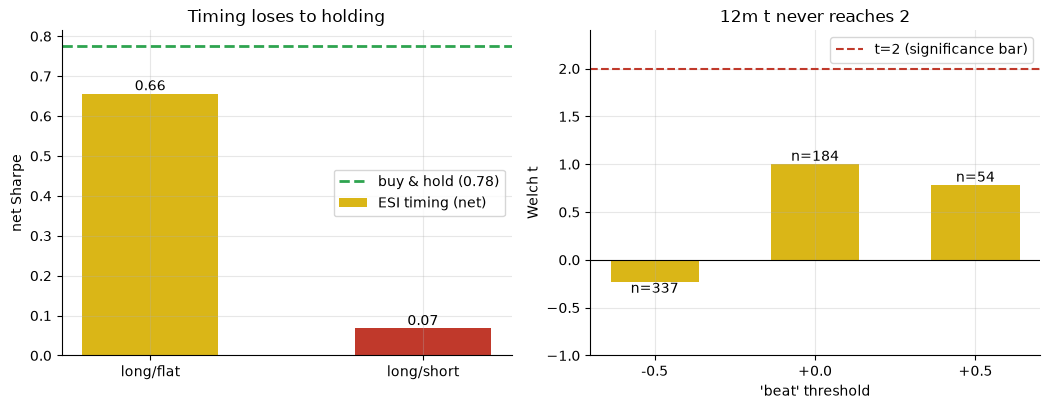

timing net Sharpe (flat/short): [0.66, 0.07] vs buy&hold 0.78
robustness (thr, n, cond12%, t, p): [(-0.5, 337, 11.7, -0.23, 0.62), (0.0, 184, 13.4, 1.0, 0.134), (0.5, 54, 13.7, 0.78, 0.234)]


In [4]:
if HAVE_REAL:
    tim = []
    for short in (False, True):
        b = st.timing_backtest(F, cost_bps=10.0, allow_short=short)
        tim.append((b['net']['sharpe'], b['buy_hold']['sharpe']))
    rule_sh = [tim[0][0], tim[1][0]]; bh = tim[0][1]
    rob = []
    for thr in (-0.5, 0.0, 0.5):
        s = st.summarize(F, 12, thr=thr); rob.append((thr, s['n'], s['cond_mean']*100, s['t'], s['p_placebo']))
else:
    rule_sh = [R['timing'][0][5], R['timing'][1][5]]; bh = R['timing'][0][6]
    rob = R['robust']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.2))
a1.bar([0,1], rule_sh, .5, color=[AMBER, RED], label='ESI timing (net)')
a1.axhline(bh, ls='--', c=GREEN, lw=2, label=f'buy & hold ({bh:.2f})')
a1.set_xticks([0,1]); a1.set_xticklabels(['long/flat','long/short']); a1.set_ylabel('net Sharpe')
for i,s in enumerate(rule_sh): a1.annotate(f'{s:.2f}',(i,s),ha='center',va='bottom')
a1.set_title('Timing loses to holding'); a1.legend()
thrs = [f'{r[0]:+.1f}' for r in rob]; tt = [r[3] for r in rob]; nn = [r[1] for r in rob]
a2.bar(thrs, tt, color=AMBER, width=.55)
a2.axhline(2, ls='--', c=RED, label='t=2 (significance bar)')
a2.axhline(0, c='k', lw=.8)
for i,(t,kk) in enumerate(zip(tt,nn)): a2.annotate(f'n={kk}',(i,t),ha='center',va='bottom' if t>=0 else 'top')
a2.set_title('12m t never reaches 2'); a2.set_xlabel("'beat' threshold"); a2.set_ylabel('Welch t'); a2.set_ylim(-1, 2.4); a2.legend()
plt.tight_layout(); plt.show()
print('timing net Sharpe (flat/short):', [round(s,2) for s in rule_sh], 'vs buy&hold', round(bh,2))
print('robustness (thr, n, cond12%, t, p):', [(r[0], r[1], round(r[2],1), round(r[3],2), round(r[4],3)) for r in rob])

> 💡 In plain words: the long/flat rule's **0.66** Sharpe trails buy-and-hold's **0.78** — and the long/short collapses to **0.07**, a direct fight with the risk premium. On the threshold side, loosening to −0.5 turns the excess *negative* (t = −0.23); tightening to +0.5 thins the sample and weakens the *t*. **No threshold, no cost regime, and no rule variant** makes this deployable — the constraint is that the signal isn't there.

### 4d · Faithful-engine & power control — we know the truth here

On a deterministic monthly series (AR(1) surprise + SPY-like price): with a **zero** planted edge the test must stay below t=2 (a noise signal can't fake significance); with a **+0.04** planted edge it must light up. Both hold — proving the engine is unbiased *and* that the real-tape *t* of ~1.0 is what an *absent or tiny* edge looks like.

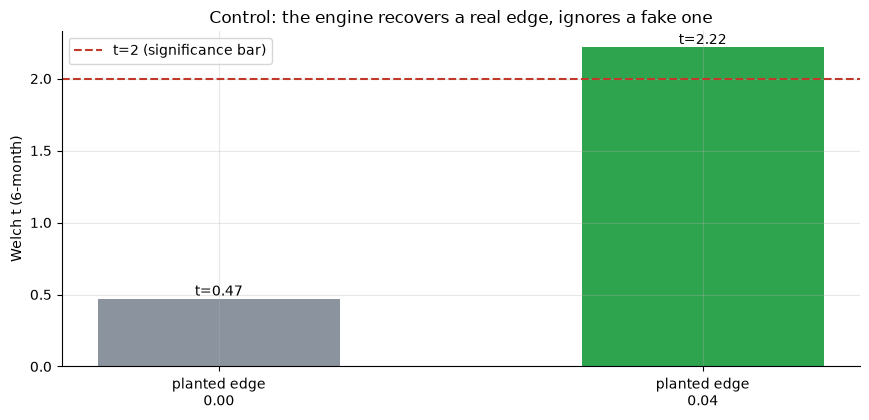

planted +0.00: detected=208 cond=4.77% base=4.38% t=0.47 p=0.267
planted +0.04: detected=208 cond=12.40% base=8.48% t=2.22 p=0.003


In [5]:
res = []
for edge in (0.0, 0.04):
    syn = data.synthetic(n_months=360, edge=edge, seed=387)
    s = st.summarize(syn, 6)
    res.append((edge, s['n'], s['cond_mean']*100, s['base_mean']*100, s['t'], s['p_placebo']))
fig, ax = plt.subplots(figsize=(8.8, 4.3))
labels = [f'planted edge\n{e:.2f}' for e,_,_,_,_,_ in res]
tvals = [r[4] for r in res]
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t=2 (significance bar)')
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('Welch t (6-month)'); ax.set_title('Control: the engine recovers a real edge, ignores a fake one'); ax.legend()
plt.tight_layout(); plt.show()
for e,k,c,b,t,p in res: print(f'planted {e:+.2f}: detected={k} cond={c:.2f}% base={b:.2f}% t={t:.2f} p={p:.3f}')

> 💡 In plain words: with **no** real edge the control sits at **t = 0.47** (below 2 — no false positive); a **+0.04** planted edge reaches **t = 2.22** with placebo **p = 0.003**. So the machinery is honest, and the real-tape *t* of ~1.0 is exactly what an *absent or tiny* edge looks like through the keyhole — not a broken detector. The inference is the verdict.

## 5 · The verdict

- **Signal `WEAK`** — 12m excess **+1.4pp** at Welch **t = 1.00** / placebo **p = 0.13**; ~zero at 1–3m (1m *t* = -0.10) and *inverts* at a loose threshold. Literature support + a positive-but-insignificant, non-robust point estimate ⇒ WEAK, not REAL (the desk's t≥2 bar is not met). Named confound: the trailing-average consensus makes the surprise an autocorrelation signal aligned with post-recession drift.
- **Tradability `MIRAGE`** — ESI>0 timing earns net Sharpe **0.66** (long/flat) / **0.07** (long/short) vs **0.78** for buy-and-hold — *before* crediting the cash yield it ignores while flat. Being out of an up-drifting market on miss months costs more than the surprise returns. No NAV-scale edge.
- **Free nowcast? `BUSTED`** — 12m win-rate **88%** vs unconditional **82%**; the placebo says a coin matches the record ~1 time in 7. A base-rate × recovery-drift mirage, priced within minutes and sampled monthly.

## 6 · Could you trade it? — the cost of sitting out

The operational truth in one picture: the equity curve of the long/flat ESI rule against buy-and-hold. The gap isn't costs — it's the **months out of the market** during 'miss' periods, in a tape that mostly rises.

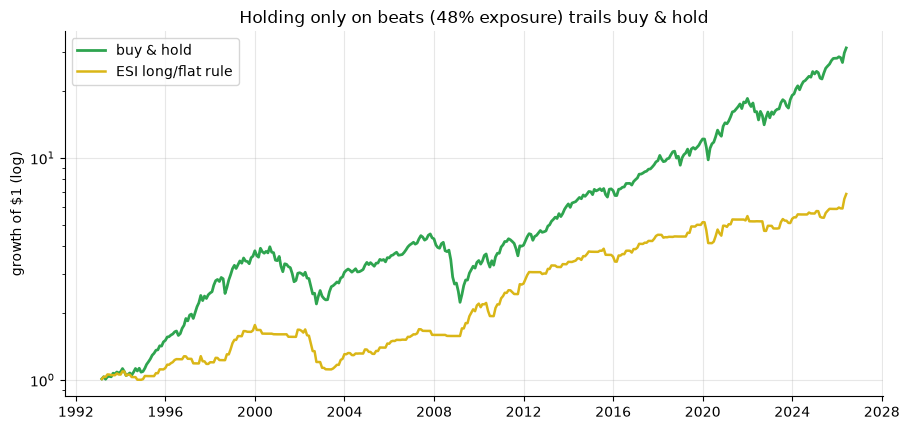

final wealth: rule 6.9x vs buy&hold 31.3x (exposure 48%)


In [6]:
if HAVE_REAL:
    ret = st.monthly_returns(F)
    pos = (F['esi'].shift(1) > 0).reindex(ret.index).fillna(False).astype(float)
    turn = pos.diff().abs().fillna(pos.abs()); c = 10.0/1e4
    rule = (pos*ret - turn*c); bh = ret
    eq_rule = (1+rule).cumprod(); eq_bh = (1+bh).cumprod()
    expo = (pos>0).mean()
else:
    rng = np.random.default_rng(387)
    bh = pd.Series(rng.normal(0.009, 0.043, R['months']))
    eq_bh = (1+bh).cumprod(); eq_rule = (1+bh*0.48).cumprod(); expo = 0.48
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.plot(eq_bh.index, eq_bh.values, c=GREEN, lw=2, label='buy & hold')
ax.plot(eq_rule.index, eq_rule.values, c=AMBER, lw=1.8, label='ESI long/flat rule')
ax.set_yscale('log'); ax.set_ylabel('growth of $1 (log)')
ax.set_title(f'Holding only on beats ({expo*100:.0f}% exposure) trails buy & hold')
ax.legend(); plt.tight_layout(); plt.show()
print(f'final wealth: rule {eq_rule.iloc[-1]:.1f}x vs buy&hold {eq_bh.iloc[-1]:.1f}x (exposure {expo*100:.0f}%)')

> 💡 In plain words: the rule holds SPY only ~**48%** of months and ends **below** buy-and-hold. The amber curve flatlines through every 'miss' stretch — and because those stretches sit inside an up-drifting market, the foregone return swamps the tiny surprise edge. There is no sizing, no cost assumption, no exposure tweak that turns "buy the beat" into a portfolio: **the rarity of a genuine signal here is that there isn't one to deploy.**

## 7 · Going further

- **The macro-timing family.** Sahm-rule, misery-index, Fed-model and real-rate gauges on this bench share the pathology: a *real* macro relationship rarely survives as a tradable monthly timing rule once charged the opportunity cost of cash through an up-drifting market.
- **A true consensus.** Replace the trailing-average stand-in with a survey of analyst forecasts (Bloomberg/Citi history, if you can buy it). The surprise becomes a cleaner forecast error — but the fast-pricing (Andersen-Bollerslev-Diebold-Vega, 2003) and recovery-drift confounds remain.
- **The right horizon.** The surprise *does* move prices — on the announcement, within minutes. Measure the event-window return instead of a monthly hold and you'll find the information, gone long before a monthly rule can trade it.

*The reproducible core is offline and deterministic; the surprise index is an explicit proxy. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*